In [ ]:
from utility.plot_from_hdf5 import plot_from_hdf5
from utility.my_colors import palette_dark, palette_light

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

RESULTS_PATH = "data/results.csv"
FIT_PARAMS_PATH = "data/fit_params.csv"
DETAILS_PATH = "data/result_details.csv"

plt.rcdefaults()

settings = {
        'font.size':16,
#         # 'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
#         # 'xtick.top':True,
#         # 'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
#         # 'ytick.right':True,
#         # 'xtick.major.size':4.0,
#         # 'xtick.minor.size':2.0,
#         # 'ytick.major.size':4.0,
#         # 'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [3]:
# load and filter results
results = pd.read_csv(RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
results = results[results["quality_flag"]==False]

# load and filter details
details = pd.read_csv(DETAILS_PATH,index_col=0,dtype={"targetid":"str"})
details = details[details["targetid"].isin(results["targetid"])]

# extract fit REW values
details["fit_rew_civ"] = details["measurements_civ"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["fit_rew"] if x != np.nan else None)
details["fit_rew_nv"] = details["measurements_nv"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["fit_rew"] if x != np.nan else None)
details["fit_rew_lya"] = details["measurements_lya"].apply(lambda x: ast.literal_eval(str(x))["further_measurements"]["fit_rew"] if x != np.nan else None)

# only keep relevant columns
details = details[['targetid', 'fit_rew_civ', 'fit_rew_nv', 'fit_rew_lya']]

# merge anc set index
results = results.merge(details,how="left",on="targetid")
results = results.set_index("targetid")

results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203806 entries, 39628261600268308 to 39627768828270015
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   rew_civ                  203806 non-null  float64
 1   rew_nv                   203775 non-null  float64
 2   rew_lya                  203802 non-null  float64
 3   snr_1700A                203804 non-null  float64
 4   snr_civ                  203806 non-null  float64
 5   snr_nv                   203805 non-null  float64
 6   snr_lya                  203805 non-null  float64
 7   pixel_used_civ           203806 non-null  float64
 8   pixel_used_blue_end_lya  203806 non-null  float64
 9   continuum_redchi         203806 non-null  float64
 10  z                        203806 non-null  float64
 11  zerr                     203806 non-null  float64
 12  civ_1549_flux            203806 non-null  float64
 13  civ_1549_flux_ivar       203806 non-n

### Check the subsequent samples like in Hamann
Objects that were processed (i.e. those from the initial SQL query) satisfy
`(zp.z BETWEEN 2.2 AND 4.38) AND (zp.zwarn=0) AND (agn.civ_1549_flux>0) AND (zp.spectype='QSO') AND zp.zcat_primary`

#### Full sample
- 2 < z 3.4 (lowest values are 2.2 not 2)
- z mag (Hamann i mag) exists, i.e. not NaN or smaller zero
- well measured CIV (here civ_flag=False, i.e. rew_civ is not NaN, pixel_used_civ > 0.7 and quality_flag=False (meaning snr_civ > 2.5, continuum_redchi < 2, also again rew_civ is not NaN))
- includes my own general quality flag within civ flag

In [4]:
full = results[(results["flux_z"] > 0) & (~results["flux_z"].isna()) & ~results["flag_civ"] & (results["z"] > 2) & (results["z"] < 3.4)]
full_idx = full.index
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,DESI J175.1786+19.9643,False,False,False,False,1.940971,10.316031,39.104673,30.873547,79.327994
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,DESI J256.8220+31.3791,False,False,False,False,2.100112,3.000584,97.040869,39.221570,80.179306
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,DESI J124.1179+04.8051,False,False,False,False,3.637961,2.566225,61.577467,51.046492,63.236045
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,DESI J261.6013+32.3681,False,False,False,False,2.312177,15.751736,38.737410,67.106677,30.577277
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,DESI J210.4780+03.2026,False,False,False,False,2.116637,3.336710,69.658606,52.529956,42.194407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,DESI J260.8952+10.9198,False,False,False,False,NaN,-1.606031,136.171891,45.596857,100.022424
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,DESI J335.1338+07.9738,False,False,False,False,1.740252,1.999649,52.427017,33.765478,41.641763
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,DESI J180.2404+05.7263,False,False,False,False,NaN,-0.849461,86.707989,32.918452,138.756640


#### W3-detected
- SNR(W3) > 3

In [5]:
w3_detected = full.query("snr_w3 > 3")
w3_detected_idx = w3_detected.index
w3_detected

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,DESI J175.1786+19.9643,False,False,False,False,1.940971,10.316031,39.104673,30.873547,79.327994
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,DESI J256.8220+31.3791,False,False,False,False,2.100112,3.000584,97.040869,39.221570,80.179306
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,DESI J261.6013+32.3681,False,False,False,False,2.312177,15.751736,38.737410,67.106677,30.577277
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,DESI J210.4780+03.2026,False,False,False,False,2.116637,3.336710,69.658606,52.529956,42.194407
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,DESI J020.8242-00.1867,False,False,False,False,5.244479,10.039528,43.257973,43.567645,18.367051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632961531806138,68.280006,61.465376,127.422601,0.520987,3.496122,3.179693,4.785442,0.933602,0.887892,0.083141,...,DESI J226.3779+33.9930,False,False,False,False,3.481394,3.462944,70.896660,74.313305,145.025455
39627915016539584,32.306415,36.275146,19.276486,0.970341,10.217814,8.539332,6.160885,0.908676,0.783715,0.737209,...,DESI J211.9961+05.1871,False,False,False,False,2.482822,12.711630,35.601777,45.084766,24.134494
39628382106812614,36.539355,31.760665,50.060707,0.803729,6.521420,5.596410,12.129493,0.982340,0.790588,0.060873,...,DESI J030.9785+25.4809,False,False,False,False,2.204676,3.416374,36.329142,30.639997,50.611621


#### ERQs
- z-W3 > 3.9

In [6]:
erq = w3_detected[w3_detected["z-w3"] > 3.9]
# results[(results["rew_civ"] > 100) & (results["flag_civ"]==False) & (results["z-w3"] > 3.9) & (2 < results["z"]) & (results["z"] < 3.4) & (results["snr_w3"] > 3)]
erq_idx = erq.index
erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,DESI J020.8242-00.1867,False,False,False,False,5.244479,10.039528,43.257973,43.567645,18.367051
39627699790024199,54.296104,49.135866,70.136264,0.736011,6.149229,4.306026,10.850016,0.966667,0.767742,0.470200,...,DESI J336.3590-03.7806,False,False,False,False,3.925658,3.459713,55.951980,46.295448,72.000721
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,DESI J246.0967+14.0559,False,False,False,False,4.990176,3.395364,131.442029,74.504683,408.076060
39628410783271554,89.148791,37.180647,54.512249,0.729147,4.183250,1.920362,4.650294,0.980296,0.872928,0.011805,...,DESI J130.1202+26.7273,False,False,False,False,4.367225,3.794841,87.107220,41.075506,58.197953
39628017118484156,69.084521,30.747853,65.695091,0.735615,3.597611,1.550206,2.602071,0.937238,0.842920,0.005644,...,DESI J224.5238+09.5670,False,False,False,False,3.922933,3.160719,68.913749,38.555854,71.679024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628257213028100,58.748484,39.964032,95.143695,0.455924,3.710882,0.931673,4.008748,0.887133,0.879093,0.037589,...,DESI J257.6106+19.7728,False,False,False,False,4.353545,4.367410,67.814057,38.808723,103.421342
39627981827606141,43.335297,37.726595,33.696240,0.820696,3.186362,1.079839,3.451561,0.958025,0.903846,0.022352,...,DESI J257.6867+07.9089,False,False,False,False,4.022404,4.672504,44.426726,31.636476,33.417698
39627567950466529,27.040848,9.697804,36.252028,0.582844,4.036805,2.470379,8.181252,0.917526,0.747706,0.079300,...,DESI J353.5923-09.1337,False,False,False,False,3.986235,5.493859,32.927110,22.278524,49.139704


#### Core ERQs
- REW(CIV) > 100

In [7]:
core_erq = erq[erq["rew_civ"] > 100]
core_erq_idx = core_erq.index
core_erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,DESI J246.0967+14.0559,False,False,False,False,4.990176,3.395364,131.442029,74.504683,408.076060
39628072797866727,470.986602,93.509273,315.010605,0.552134,4.489033,1.061074,3.148873,0.953431,0.923497,0.011409,...,DESI J358.3632+11.6377,False,False,False,False,5.039216,3.525600,479.411154,121.484755,337.753605
39627891113201923,112.219588,62.672895,99.054101,0.606324,5.955274,2.710882,7.278569,0.983945,0.908163,0.016740,...,DESI J223.5077+04.3459,False,False,False,False,4.769846,5.128605,109.927749,64.175805,97.136269
39627780903669053,140.798530,249.117161,53.101180,0.543534,4.137893,5.718557,1.320132,0.901119,0.854470,0.004901,...,DESI J132.1420-00.3633,False,False,False,False,6.028903,4.514986,146.049805,299.202272,138.779761
39628396275177020,171.882397,39.498231,197.261087,0.697958,4.498471,0.809909,6.562073,0.978599,0.891540,0.002679,...,DESI J246.8974+25.8897,False,False,False,False,4.020581,3.095826,163.272381,29.507003,190.096757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632971719774209,107.142013,40.204052,90.573330,0.451184,2.535676,0.928699,2.889068,0.950237,0.883905,0.026021,...,DESI J239.5659+34.5843,False,False,False,False,4.514094,3.249171,117.220389,52.817816,106.850193
39627606353513953,262.600709,133.373283,372.368041,0.875102,4.632945,2.508304,5.879460,0.912281,0.878049,0.042191,...,DESI J144.6870-07.5005,False,False,False,False,5.390509,8.135670,278.324675,143.146019,404.085167
39627897656312134,177.743800,54.117060,459.072967,1.142572,3.396098,0.698038,2.474661,0.840580,0.902965,0.022673,...,DESI J254.2128+04.4398,False,False,False,False,4.860401,4.469538,184.299865,48.875308,509.715404


In [8]:
large = full.query("rew_civ > 100")
large

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39628412662323165,161.601504,66.853313,24.886163,0.661391,5.145252,2.287900,1.508265,0.990172,0.836066,0.051041,...,DESI J255.4219+26.7486,False,False,False,False,1.181962,1.124340,161.701284,97.918390,46.506675
39628481855754778,149.066299,45.077878,88.992064,0.626327,4.060759,1.097277,2.594436,0.956190,0.881356,0.008430,...,DESI J257.7142+29.9932,False,False,False,False,1.599139,0.157900,154.913580,52.837864,110.339125
39627985698953905,134.089950,59.402374,94.582893,0.558191,8.832818,2.819567,7.060071,0.993135,0.884615,0.168216,...,DESI J130.7657+08.1379,False,False,False,False,2.596950,1.163219,131.525286,59.768305,98.564059
39627497754594111,107.996366,35.047851,123.960369,0.423711,6.565238,1.992941,7.510495,0.963325,0.925824,0.083516,...,DESI J060.8959-12.0943,False,False,False,False,1.238204,0.206148,109.140744,35.319866,123.191551
39628495797618139,181.144207,35.396888,159.440111,0.747491,3.404237,1.493232,2.868796,0.917595,0.863524,0.026513,...,DESI J138.8743+30.7987,False,False,False,False,0.062326,0.036952,209.654921,66.708317,202.723108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39627766093584889,100.659055,34.724141,74.987139,0.694299,4.940178,1.772425,5.475085,0.967442,0.888601,0.020050,...,DESI J329.4479-00.8818,False,False,False,False,2.953357,1.218513,100.157547,44.420492,81.118414
39628337403923861,104.989620,31.105850,101.069486,0.652475,4.819678,0.978631,3.843473,0.977612,0.889197,0.066478,...,DESI J350.4140+23.1826,False,False,False,False,NaN,-0.383397,105.398099,31.079209,98.970324
39628259347926729,113.953401,41.878910,118.952360,0.715565,4.402226,1.670195,2.452027,0.949398,0.908602,0.030174,...,DESI J032.5745+20.0769,False,False,False,False,NaN,-0.802420,115.530457,55.373829,144.621351


#### ERQ-like

In [9]:
erq_like = results[(results["flux_z"] > 0) & (~results["flux_z"].isna()) & ~results["flag_civ"] & (results["z"] > 2) & (results["z"] < 4) & (results["snr_w3"] > 3) & (results["z-w3"] > 3.9) & (results["rew_civ"] > 100)]
erq_like

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,desiname,quality_flag,flag_civ,flag_nv,flag_lya,z-w3,snr_w3,fit_rew_civ,fit_rew_nv,fit_rew_lya
targetid,,,,,,,,,,,,,,,,,,,,,
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,DESI J246.0967+14.0559,False,False,False,False,4.990176,3.395364,131.442029,74.504683,408.076060
39628072797866727,470.986602,93.509273,315.010605,0.552134,4.489033,1.061074,3.148873,0.953431,0.923497,0.011409,...,DESI J358.3632+11.6377,False,False,False,False,5.039216,3.525600,479.411154,121.484755,337.753605
39627891113201923,112.219588,62.672895,99.054101,0.606324,5.955274,2.710882,7.278569,0.983945,0.908163,0.016740,...,DESI J223.5077+04.3459,False,False,False,False,4.769846,5.128605,109.927749,64.175805,97.136269
39627780903669053,140.798530,249.117161,53.101180,0.543534,4.137893,5.718557,1.320132,0.901119,0.854470,0.004901,...,DESI J132.1420-00.3633,False,False,False,False,6.028903,4.514986,146.049805,299.202272,138.779761
39628396275177020,171.882397,39.498231,197.261087,0.697958,4.498471,0.809909,6.562073,0.978599,0.891540,0.002679,...,DESI J246.8974+25.8897,False,False,False,False,4.020581,3.095826,163.272381,29.507003,190.096757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632971719774209,107.142013,40.204052,90.573330,0.451184,2.535676,0.928699,2.889068,0.950237,0.883905,0.026021,...,DESI J239.5659+34.5843,False,False,False,False,4.514094,3.249171,117.220389,52.817816,106.850193
39627606353513953,262.600709,133.373283,372.368041,0.875102,4.632945,2.508304,5.879460,0.912281,0.878049,0.042191,...,DESI J144.6870-07.5005,False,False,False,False,5.390509,8.135670,278.324675,143.146019,404.085167
39627897656312134,177.743800,54.117060,459.072967,1.142572,3.396098,0.698038,2.474661,0.840580,0.902965,0.022673,...,DESI J254.2128+04.4398,False,False,False,False,4.860401,4.469538,184.299865,48.875308,509.715404


### Plots

#### Evaluate method

In [10]:
# full.to_csv("data/local/full_subset.csv")
full = pd.read_csv("data/local/full_subset.csv",dtype={"targetid":"str"})
full = full.set_index("targetid")
full = full.drop(index=["39627636372146550"])

#### Histogram: REW(CIV) colored by object type

In [11]:
histplot_df = full.copy()

histplot_df["Sample"] = "Full"
for elem in histplot_df.index:
    # if elem in core_erq_idx: 
    if elem in erq_idx:
        histplot_df.loc[elem,"Sample"] = "ERQ"
    elif elem in w3_detected_idx:
        histplot_df.loc[elem,"Sample"] = "W3 detected"

histplot_df = histplot_df[["rew_civ","Sample"]].copy()

[]

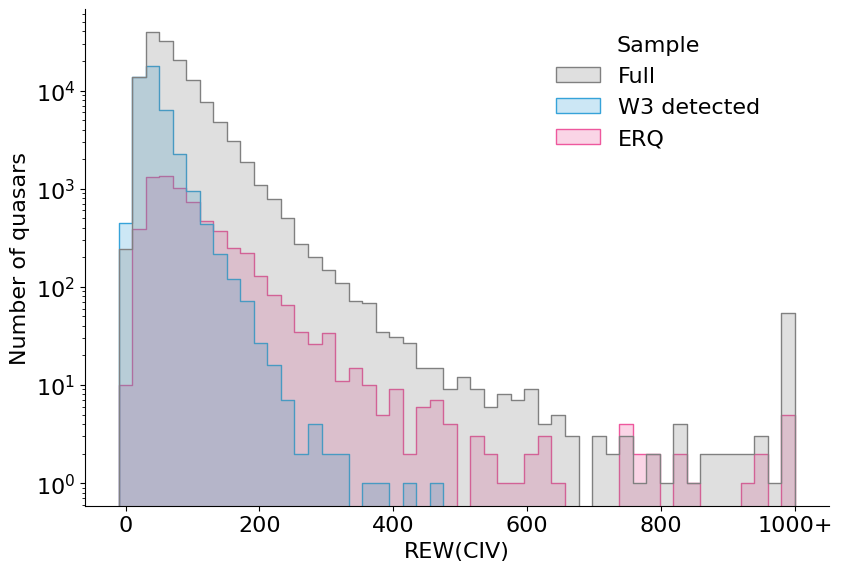

In [107]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

histplot_df["rew_civ"] = histplot_df["rew_civ"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=histplot_df, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=["Full","W3 detected","ERQ"],palette=["gray",palette_dark[2],palette_dark[0]],height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

xticks = list(range(0,1001,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "1000+"
ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("REW(CIV)")
plt.ylabel("Number of quasars")

plt.tight_layout()

plt.savefig("images/histo v3.svg")

plt.plot()

#### Contour plot: z vs color

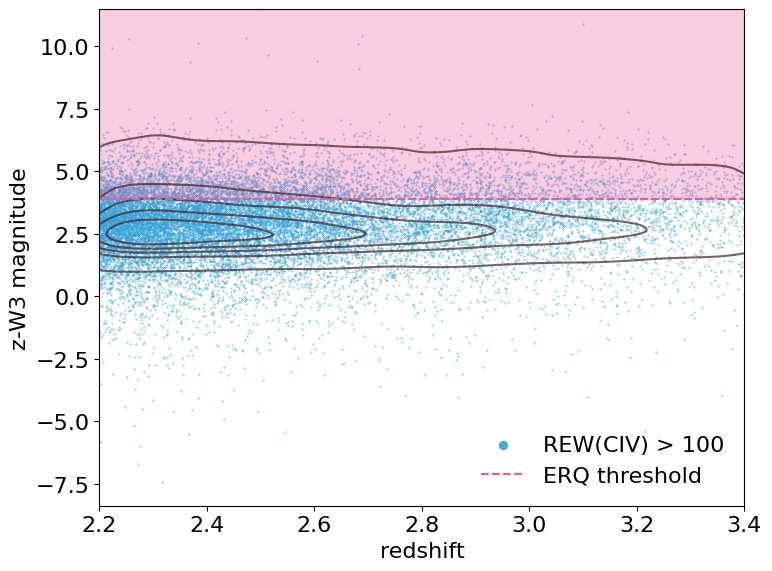

In [109]:
# plt.hist2d(w3_detected["z"],w3_detected["z-w3"])
fig, ax = plt.subplots(figsize=(8,6))
sns.kdeplot(data=w3_detected,x="z",y="z-w3",fill=False,color="#442222",cut=0,label="W3 detected",thresh=1E-02,alpha=0.7,levels=6,ax=ax)
plt.scatter(large["z"],large["z-w3"],s=0.1,alpha=0.9,color=palette_dark[2],label="REW(CIV) > 100")

plt.axhline(3.9,label="ERQ threshold",color=palette_dark[0],linestyle="--")

lower_ylim, upper_ylim = ax.get_ylim()
plt.axhspan(3.9,upper_ylim, color=palette_dark[0], alpha=0.3)

plt.xlim(2.2,3.4)
plt.ylim(lower_ylim,upper_ylim)
leg = plt.legend(frameon=False,markerscale=18,loc="lower right")

        
plt.xlabel("redshift")
plt.ylabel("z-W3 magnitude")

plt.tight_layout()

plt.savefig("images/contour.svg")

plt.show()

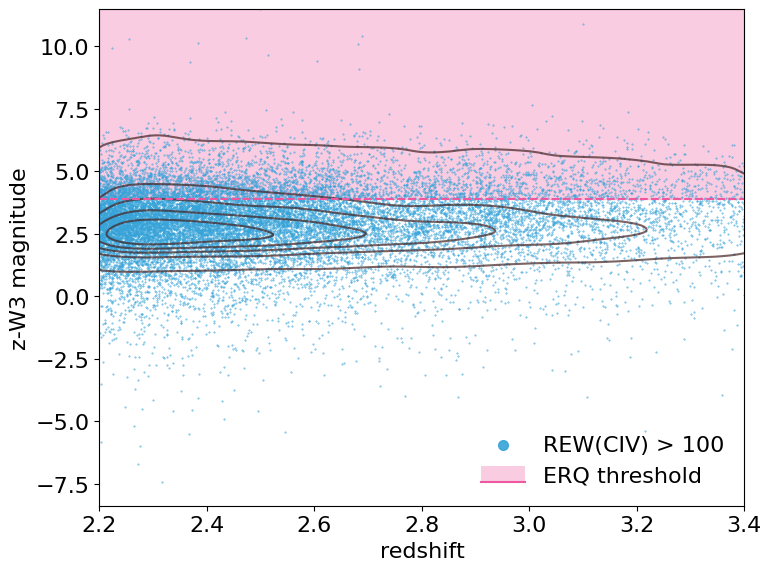

In [110]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

class HandlerShadedBottomBorder(HandlerBase):
    """Legend handle: shaded box with a border only on the bottom edge."""
    def __init__(self, facecolor, edgecolor, alpha=0.3, linewidth=1.5, **kwargs):
        self.facecolor = facecolor
        self.edgecolor = edgecolor
        self.alpha = alpha
        self.linewidth = linewidth
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                        xdescent, ydescent, width, height, fontsize, trans):
        rect = Rectangle(
            (-xdescent, -ydescent), width, height,
            facecolor=self.facecolor, alpha=self.alpha,
            edgecolor="none", transform=trans
        )
        bottom_line = Line2D(
            [-xdescent, -xdescent + width], [-ydescent, -ydescent],
            color=self.edgecolor, linewidth=self.linewidth, transform=trans
        )
        return [rect, bottom_line]

fig, ax = plt.subplots(figsize=(8,6))
sns.kdeplot(data=w3_detected,x="z",y="z-w3",fill=False,color="#442222",
            cut=0,label="W3 detected",thresh=1E-02,alpha=0.7,levels=6,ax=ax)

# lower_ylim, upper_ylim = ax.get_ylim()
plt.axhspan(3.9,upper_ylim, color=palette_dark[0], alpha=0.3)

plt.scatter(large["z"],large["z-w3"],s=0.15,alpha=0.9,color=palette_dark[2],label="REW(CIV) > 100")

plt.axhline(3.9,color=palette_dark[0],linestyle="--")  # no label now, legend entry built manually



plt.xlim(2.2,3.4)
plt.ylim(lower_ylim,upper_ylim)

# proxy handle for the custom legend entry
erq_proxy = Patch(facecolor="none", edgecolor="none", label="ERQ threshold")

handles, labels = ax.get_legend_handles_labels()
handles.append(erq_proxy)
labels.append("ERQ threshold")

leg = ax.legend(
    handles, labels,
    frameon=False, markerscale=18, loc="lower right",
    handler_map={erq_proxy: HandlerShadedBottomBorder(
        facecolor=palette_dark[0], edgecolor=palette_dark[0], alpha=0.3, linewidth=1.5
    )}
)

plt.xlabel("redshift")
plt.ylabel("z-W3 magnitude")

plt.tight_layout()

plt.savefig("images/contour v2.svg")

plt.show()

In [ ]:
# i = 1578

# targetid = "39627636372146550"#core_erq.index[i]

# plot_from_hdf5(targetid,CIV=True,NV=True,LYA=True,smoothing_strength=6,title=full.loc[targetid,"desiname"])